In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\World-happiness-report-2024.csv")
print(df)

         Country name            Regional indicator  Ladder score  \
0             Finland                Western Europe         7.741   
1             Denmark                Western Europe         7.583   
2             Iceland                Western Europe         7.525   
3              Sweden                Western Europe         7.344   
4              Israel  Middle East and North Africa         7.341   
..                ...                           ...           ...   
138  Congo (Kinshasa)            Sub-Saharan Africa         3.295   
139      Sierra Leone            Sub-Saharan Africa         3.245   
140           Lesotho            Sub-Saharan Africa         3.186   
141           Lebanon  Middle East and North Africa         2.707   
142       Afghanistan                    South Asia         1.721   

     upperwhisker  lowerwhisker  Log GDP per capita  Social support  \
0           7.815         7.667               1.844           1.572   
1           7.665         7.5

In [4]:
pd.read_csv("C:\\Users\\Admin\\Downloads\\World-happiness-report-2024.csv")

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298
...,...,...,...,...,...,...,...,...,...,...,...,...
138,Congo (Kinshasa),Sub-Saharan Africa,3.295,3.462,3.128,0.534,0.665,0.262,0.473,0.189,0.072,1.102
139,Sierra Leone,Sub-Saharan Africa,3.245,3.366,3.124,0.654,0.566,0.253,0.469,0.181,0.053,1.068
140,Lesotho,Sub-Saharan Africa,3.186,3.469,2.904,0.771,0.851,0.000,0.523,0.082,0.085,0.875
141,Lebanon,Middle East and North Africa,2.707,2.797,2.616,1.377,0.577,0.556,0.173,0.068,0.029,-0.073


In [5]:
print('\nMissing Values')
print(df.isnull().sum())


Missing Values
Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64


In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Dystopia + residual             0
dtype: int64


In [7]:

print('\nTop 10 happiest country:')
top= df.sort_values(by = 'Ladder score',ascending= False).head(10)
print(top[['Country name']])


Top 10 happiest country:
  Country name
0      Finland
1      Denmark
2      Iceland
3       Sweden
4       Israel
5  Netherlands
6       Norway
7   Luxembourg
8  Switzerland
9    Australia


In [8]:
print('\nRegion-wise happiness comparison:')
region =df.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending=False)
print(region)


Region-wise happiness comparison:
Regional indicator
North America and ANZ                 6.927750
Western Europe                        6.841650
Central and Eastern Europe            6.170941
Latin America and Caribbean           6.143368
East Asia                             5.934333
Southeast Asia                        5.551889
Commonwealth of Independent States    5.538500
Middle East and North Africa          5.199941
Sub-Saharan Africa                    4.329686
South Asia                            3.895667
Name: Ladder score, dtype: float64


In [9]:
df['Rank'] = df['Log GDP per capita'].rank(ascending=False,method = 'min')
sorted = df.sort_values(by = 'Rank')
print(sorted[['Country name','Rank']].head(10))

                 Country name  Rank
7                  Luxembourg   1.0
16                    Ireland   2.0
29                  Singapore   3.0
21       United Arab Emirates   4.0
8                 Switzerland   5.0
6                      Norway   6.0
22              United States   7.0
85  Hong Kong S.A.R. of China   8.0
1                     Denmark   9.0
5                 Netherlands  10.0


In [10]:
gap =df['Happiness Gap'] = df['upperwhisker'] - df['lowerwhisker']
print(gap.head(10))

0    0.148
1    0.165
2    0.185
3    0.155
4    0.128
5    0.127
6    0.174
7    0.182
8    0.174
9    0.168
dtype: float64


In [11]:
print(df['Social support'].describe())

count    143.000000
mean       1.134329
std        0.329777
min        0.000000
25%        0.924500
50%        1.217000
75%        1.377000
max        1.617000
Name: Social support, dtype: float64


Data Visualization:

Correlation matrix:
 Ladder score                    1.000000
lowerwhisker                    0.999697
upperwhisker                    0.999678
Social support                  0.812142
Log GDP per capita              0.767181
Healthy life expectancy         0.758352
Freedom to make life choices    0.643342
Dystopia + residual             0.532624
Perceptions of corruption       0.451052
Generosity                      0.129815
Happiness Gap                  -0.481159
Rank                           -0.791002
Name: Ladder score, dtype: float64


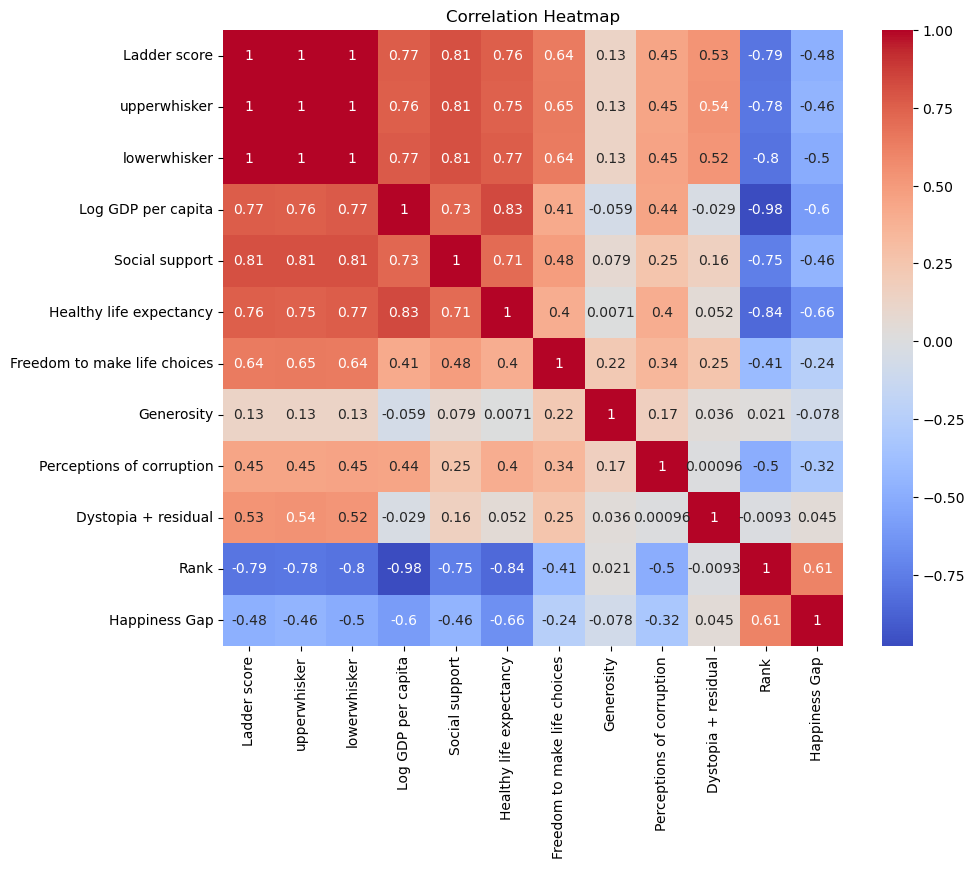

In [25]:
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()
print("Correlation matrix:\n", correlation['Ladder score'].sort_values(ascending=False))
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

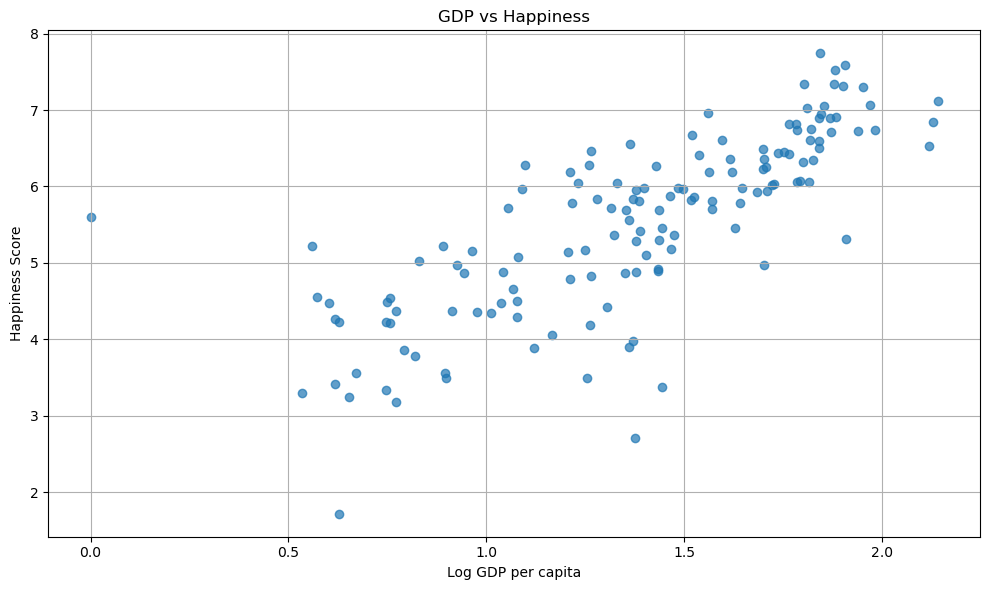

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(df['Log GDP per capita'], df['Ladder score'], alpha=0.7)
plt.xlabel('Log GDP per capita')
plt.ylabel('Happiness Score')
plt.title('GDP vs Happiness')
plt.grid(True)
plt.tight_layout()
plt.show()

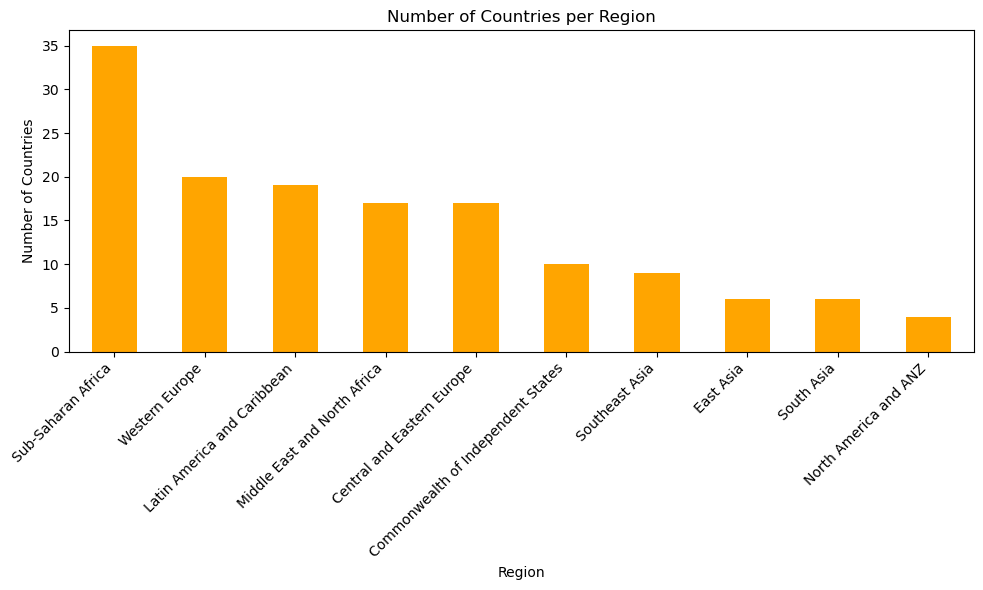

In [27]:
region_count = df['Regional indicator'].value_counts()

plt.figure(figsize=(10,6))
region_count.plot(kind='bar', color='orange')
plt.xlabel('Region')
plt.ylabel('Number of Countries')
plt.title('Number of Countries per Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

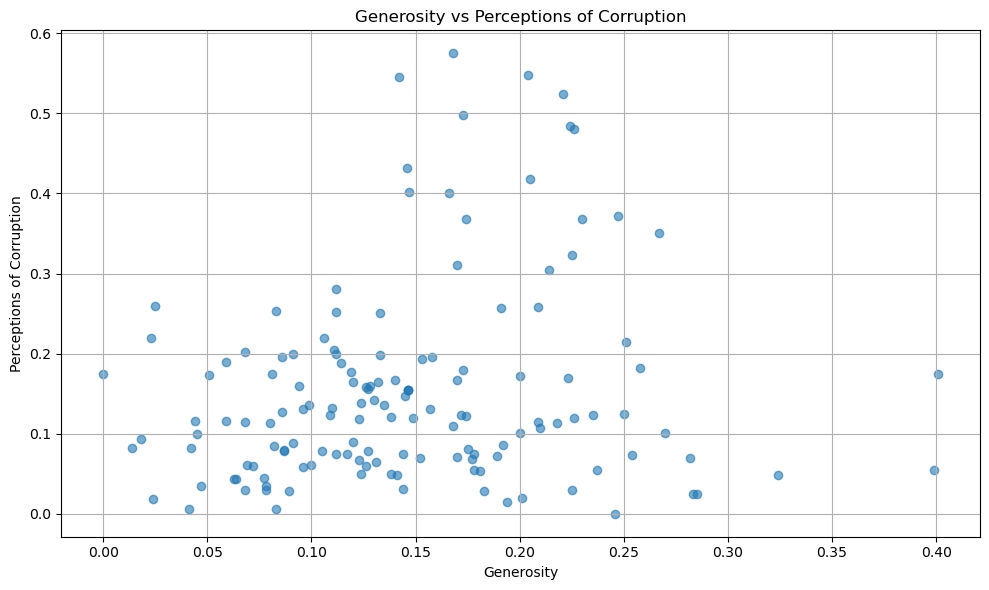

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(df['Generosity'], df['Perceptions of corruption'], alpha=0.6)
plt.xlabel('Generosity')
plt.ylabel('Perceptions of Corruption')
plt.title('Generosity vs Perceptions of Corruption')
plt.grid(True)
plt.tight_layout()
plt.show()

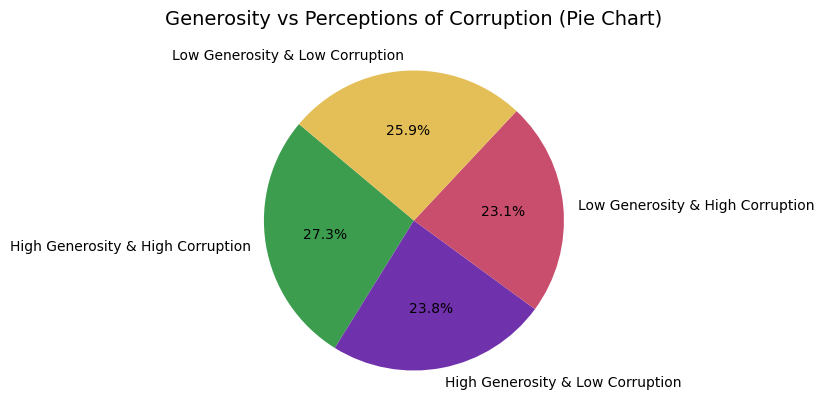

In [14]:
import numpy as np
gen_median = df['Generosity'].median()
cor_median = df['Perceptions of corruption'].median()


conditions = [
    (df['Generosity'] >= gen_median) & (df['Perceptions of corruption'] >= cor_median),
    (df['Generosity'] >= gen_median) & (df['Perceptions of corruption'] < cor_median),
    (df['Generosity'] < gen_median) & (df['Perceptions of corruption'] >= cor_median),
    (df['Generosity'] < gen_median) & (df['Perceptions of corruption'] < cor_median)
]

labels = [
    'High Generosity & High Corruption',
    'High Generosity & Low Corruption',
    'Low Generosity & High Corruption',
    'Low Generosity & Low Corruption'
]


counts = [np.sum(cond) for cond in conditions]
plt.figure(figsize=(8,8))
colors = [ '#3c9d4e','#7031ac','#c94d6d','#e4bf58']
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 10})
plt.title('Generosity vs Perceptions of Corruption (Pie Chart)', fontsize=14)
plt.tight_layout()
plt.show()
